In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress
from sklearn.metrics import r2_score
from tqdm import tqdm

import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
def sample_power_law(xmin_spl, xmax_spl, b_spl, distribution_spl):
    """Samples particle sizes following a power-law distribution."""
    exponent = b_spl + 1
    norm = xmax_spl**exponent - xmin_spl**exponent
    MP_size = (distribution_spl * norm + xmin_spl**exponent) ** (1 / exponent)
    return MP_size
    

In [3]:
def simulated_sampling(xmin_ss, xmax_ss, LOD_min_ss, LOD_max_ss, b_ss, samples_ss):
    """Sample particles from power-law distribution within LOD bounds."""
    part_sampled = sample_power_law(LOD_min_ss, LOD_max_ss, b_ss, samples_ss) # if we dont have N
    if len(part_sampled)==0: print('Problem: There is not enough particles in the LOD range')
    return np.sort(part_sampled) 
    

In [4]:
# Binning and cumulative sum
def cumulative_sum(bins_cs, samplings_cs):
    """Return cumulative sum for each sampling over the bins."""
    lower_bin_limits = bins_cs
    cumulative_counts_all_samplings = []
    for i in range(len(samplings_cs)):
        cumulative_counts = np.array([(samplings_cs[i] >= limit).sum() for limit in lower_bin_limits])
        cumulative_counts_all_samplings.append(cumulative_counts)
    return cumulative_counts_all_samplings
    

In [5]:
def determine_bin_threshold(n_sample, LOD_min, slope_th):
    
    """
    Function used for error evaluation exculsively.
    Customed rules to define threshold based on observed cases.
    Threshold can be modified if not coherent with input parameters.
    """
    
    # Custom cases based on updated user rules
    if slope_th == -3.4 and LOD_min == 5 and n_sample > 1000:
        threshold = 6
        return 0,threshold
    if LOD_min > 50 and 250 < n_sample < 650:
        threshold = 3
        return 1,threshold
    if slope_th > -2 and LOD_min > 50:
        threshold = 3
        return 2, threshold
    if slope_th > -1.4:
        threshold =  7  # override any previously set threshold 10
        return 3, threshold

    # Base cases
    if n_sample <= 50:
        if LOD_min > 130:
            threshold = 3
            return 4,threshold
        elif slope_th <= -2:
            threshold=  3
            return 5,threshold
        else:
            threshold= 6
            return 6,threshold
            
    elif n_sample >= 1000:
        if LOD_min > 130:
            threshold= 5
            return 7,threshold
        else:
            threshold= 7
            return 8,threshold
    else:
        threshold= 3
        return 9,threshold

In [6]:
def plot_threshold_diagnostic(lower_bins, cumulative_counts, minimal_bins_used, slope, intercept):
    """Plot diagnostic showing bins used vs. removed."""
    plt.figure(figsize=(6, 4))
    plt.loglog(lower_bins, cumulative_counts, 'ko-', label='All bins')
    plt.loglog(lower_bins[:minimal_bins_used], cumulative_counts[:minimal_bins_used], 'go-', label='Kept bins')
    plt.loglog(lower_bins[minimal_bins_used:], cumulative_counts[minimal_bins_used:], 'ro-', label='Dropped bins')
    x_fit = lower_bins
    y_fit = 10 ** (slope * np.log10(x_fit) + intercept)
    plt.loglog(x_fit, y_fit, 'b--', label='Linear fit')
    plt.xlabel('Lower bin limit')
    plt.ylabel('Cumulative count')
    plt.title('Threshold diagnostic')
    plt.legend()
    plt.tight_layout()
    plt.show()
    

In [16]:
def evaluation_of_binsize(modify,minimal_bins_used, cumulative_counts_all_samplings_eb, lower_bin_limits_eb, slope_th, plot_debug=False):
    """Evaluate slope error and plot diagnostics."""
    slopes_all_samplings = []
    intercepts_all_samplings = []
    slope_err_all_samplings = []
    r2_all_samplings= []
    N_all_samplings=[]
    
    for i in range(len(cumulative_counts_all_samplings_eb)):
        counts = cumulative_counts_all_samplings_eb[i]
        if len(counts) < minimal_bins_used:
            print('Problem: There is not enough bins. Change threshold', modify)
            continue
        counts_kept = counts[:minimal_bins_used]
        bins_kept = lower_bin_limits_eb[:minimal_bins_used]
        if counts_kept[-1] < 1:
            print('Problem: There is not enough particles in the last bin. Change threshold',modify)
            continue
        log_bins = np.log10(bins_kept)
        log_counts = np.log10(counts_kept)
        slope, intercept, *_ = linregress(log_bins, log_counts) ### *_ ignores following variables
        slope_noncumul = slope - 1
        slope_err = slope_noncumul - slope_th
        r2 = r2_score(log_counts, slope * log_bins + intercept)
        slopes_all_samplings.append(slope)
        intercepts_all_samplings.append(intercept)
        slope_err_all_samplings.append(slope_err)
        r2_all_samplings.append(r2)
        
        N1=slope*np.log10(1)+intercept
        N5000=slope*np.log10(100)+intercept
        N=10**N1-10**N5000
        N_all_samplings.append(N)
        
        if plot_debug and i == 0:
            print('slope:',slope_th,'LOD:',bins_kept[0], 'n:', counts_kept[0])
            plot_threshold_diagnostic(lower_bin_limits_eb, counts, minimal_bins_used, slope, intercept)

    if not slopes_all_samplings:
        return None
        
    mean_N=np.mean(N_all_samplings)
    error_on_N=np.absolute(mean_N-N_all_samplings)
    N_error=np.mean(error_on_N)/mean_N
    
    slope_err_all_samplings = np.abs(slope_err_all_samplings)
    return {
        'mean_slope_err': np.mean(slope_err_all_samplings),
        'r2': np.mean(r2_all_samplings),
        'N_error': N_error
    }
    

In [8]:
### Parameters ###

slopes = np.linspace(-3.4, -1.1, 5)
LODs = np.linspace(10, 505,10 )
LOD_max = 5000 # by choice
ns = np.linspace(100, 2000, 10, dtype=int)

xmin, xmax = 1, 5000
random_distributions_number = 200
results = []

In [9]:
for slope_th in tqdm(slopes, desc="Slope loop"):
    for LOD_min in LODs:
        # Bin generation with step *= 1.5 pattern
        if LOD_min <= 50 : step = 2
        elif 100 <= LOD_min <= 200 : step = 5
        elif LOD_min >= 200 and slope_th >= -2. :step = 15
        else : step =10
        edges = [LOD_min]
        while True:
            next_edge = edges[-1] + step
            if next_edge >= xmax:
                break
            edges.append(next_edge)
            step *= 1.5
        bin_edges = np.array(edges)
        
        for n_sampled in ns:
            all_samplings = []

            for distribution in range(random_distributions_number):
                random_sequence = np.random.uniform(0, 1, n_sampled)
                size_distribution = simulated_sampling(xmin_ss=xmin, xmax_ss=xmax,
                LOD_min_ss=LOD_min, LOD_max_ss=LOD_max,b_ss=slope_th, samples_ss=random_sequence)
                all_samplings.append(size_distribution)

            cumulative_counts = cumulative_sum(bin_edges, all_samplings)
            to_be_modified,bin_threshold = determine_bin_threshold(n_sampled, LOD_min, slope_th)

            result = evaluation_of_binsize(modify=to_be_modified,
                minimal_bins_used=bin_threshold,
                cumulative_counts_all_samplings_eb=cumulative_counts,
                lower_bin_limits_eb=bin_edges,slope_th=slope_th,plot_debug=True)
            
            if result is not None:
                results.append([slope_th, LOD_min, n_sampled, result['mean_slope_err'],result['N_error']])
            else: print('Problem in evaluation of binsize')
            

Slope loop: 100%|██████████| 5/5 [02:17<00:00, 27.59s/it]


In [10]:
results_df = pd.DataFrame(results, columns=['slope', 'LOD', 'n', 'slope_error', 'N_error'])
results_x10 = results_df[results_df['N_error'] >= 1]


In [11]:
results_df['LOD']=results_df['LOD'].apply(lambda x: round(x, 0))

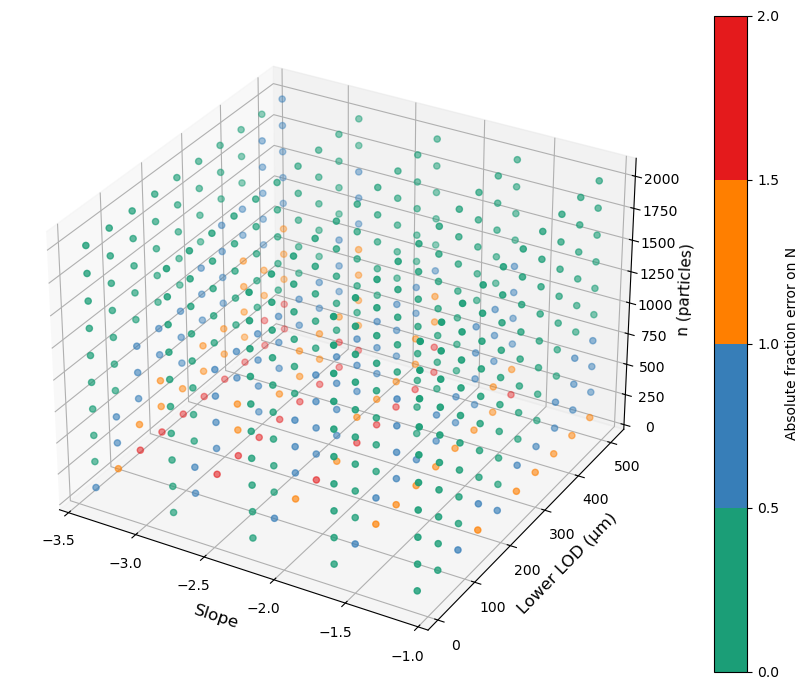

In [12]:
boundaries = [0,0.5, 1, 1.5, 2, ]  # You can extend this range if needed
colors = ['#1b9e77', '#377eb8', '#ff7f00', '#e41a1c',]  # green, blue, orange, red, dark red

# Color-blind safe palette (ColorBrewer / Okabe-Ito inspired)
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, len(colors))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    results_df['slope'],
    results_df['LOD'],
    results_df['n'],
    c=results_df['N_error'],
    cmap=cmap,
    norm=norm,
)

ax.set_xlabel('Slope',fontsize=12)
ax.set_ylabel('Lower LOD (µm)',fontsize=12)
ax.set_zlabel('n (particles)',fontsize=11)
ax.set_title('')
fig.colorbar(sc, ax=ax, label='Absolute fraction error on N')
plt.tight_layout()


In [13]:
n_fixed = 50  # or pick another value you want
LOD_fixed = 505  # or pick another value you want

# Filter the data
df_slice = results_df[results_df['n'] == n_fixed]

# Optional: sort to ensure consistency in plotting
df_slice = df_slice.sort_values(by=['n', 'LOD'])
df_slice2 = df_slice[df_slice['LOD'] == LOD_fixed]

pivot = df_slice2.pivot(index='LOD', columns='slope', values='slope_error')


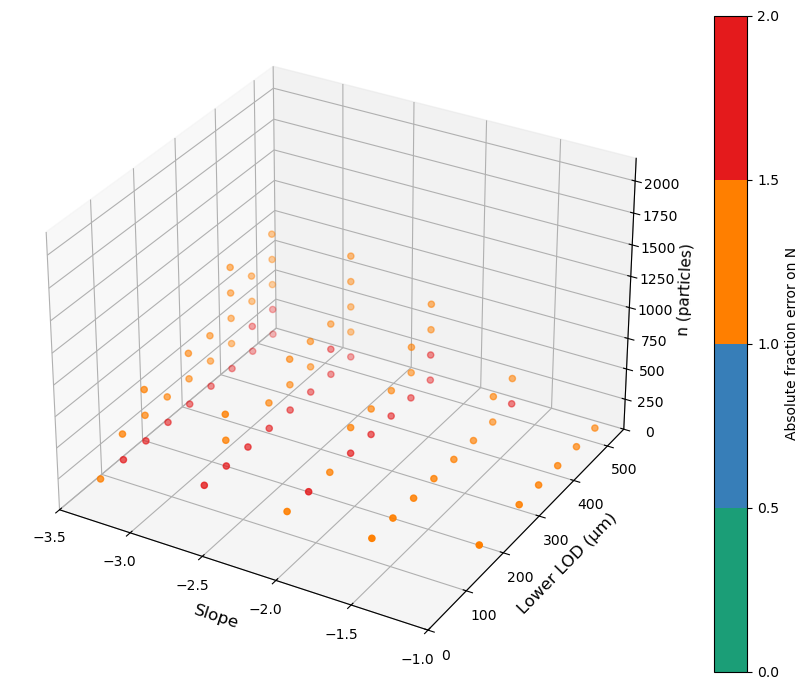

In [15]:
boundaries = [0,0.5, 1, 1.5, 2, ]  # You can extend this range if needed
colors = ['#1b9e77', '#377eb8', '#ff7f00', '#e41a1c',]  # green, blue, orange, red, dark red

# Color-blind safe palette (ColorBrewer / Okabe-Ito inspired)
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, len(colors))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    results_x10['slope'],
    results_x10['LOD'],
    results_x10['n'],
    c=results_x10['N_error'],
    cmap=cmap,
    norm=norm,
)

ax.set_xlim(-3.5,-1)
ax.set_ylim(0,550)
ax.set_zlim(0,2175)
ax.set_xlabel('Slope',fontsize=12)
ax.set_ylabel('Lower LOD (µm)',fontsize=12)
ax.set_zlabel('n (particles)',fontsize=11)
ax.set_title('')
fig.colorbar(sc, ax=ax, label='Absolute fraction error on N')
plt.tight_layout()
